In [1]:
 
import numpy as np 
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import math
import pandas as pd 
import matplotlib.pyplot as plt

# import seaborn as sns
import sklearn.metrics as metrics
%matplotlib inline
import os
from pandas_ml import ConfusionMatrix

In [2]:
data = pd.read_csv('CIC-IDS-2017-9.csv')
# test = pd.read_csv('UNSW_NB15_testing-set.csv')
# combined_data = pd.concat([train, test]).drop(['id'],axis=1)
combined_data = data

In [3]:
combined_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.005989,0.939505,0.000149,0.000056,0.005220,8.063796e-06,0.016237,0.000000,0.033918,0.029041,...,0.571429,0.000003,3.124006e-07,0.000003,2.688679e-06,0.134167,0.006512,0.136667,0.128333,BENIGN
1,0.000000,0.947978,0.002616,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.088319,1.453303e-01,0.178302,1.792453e-07,0.101667,0.090546,0.173333,0.045875,BENIGN
2,0.082451,0.000834,0.000101,0.000000,0.000499,0.000000e+00,0.001128,0.012043,0.004713,0.000000,...,0.571429,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,BENIGN
3,0.000000,0.000456,0.000014,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,BENIGN
4,0.001355,0.000005,0.000029,0.000014,0.000392,6.602871e-07,0.009388,0.000000,0.011639,0.015883,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,BENIGN


In [4]:
vector = combined_data[' Label']

In [5]:
from sklearn.preprocessing import LabelEncoder,normalize
le1 = LabelEncoder()
le = LabelEncoder()

vector = combined_data[' Label']
print("Label:", set(list(vector))) # use print to make it print on single line 

combined_data[' Label'] = le1.fit_transform(vector)
# combined_data['proto'] = le.fit_transform(combined_data['proto'])
# combined_data['service'] = le.fit_transform(combined_data['service'])
# combined_data['state'] = le.fit_transform(combined_data['state'])

vector = combined_data[' Label']

Label: {'BENIGN', 'Bot'}


In [6]:
# combined_data = data[~data['Label'].isin([2])] 

In [7]:
y_label = combined_data.iloc[:,78].values.flatten()
dict = {}
for i in y_label:
    dict.update({i:dict.get(i,0)+1})
dict

{0: 189067, 1: 1966}

In [8]:
le1.inverse_transform([0,1])
combined_data.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.005989,0.939505,0.000149,0.000056,0.005220,0.000008,0.016237,0.000000,0.033918,0.029041,...,0.571429,0.000003,3.124006e-07,0.000003,2.688679e-06,0.134167,0.006512,0.136667,0.128333,0
1,0.000000,0.947978,0.002616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.088319,1.453303e-01,0.178302,1.792453e-07,0.101667,0.090546,0.173333,0.045875,0
2,0.082451,0.000834,0.000101,0.000000,0.000499,0.000000,0.001128,0.012043,0.004713,0.000000,...,0.571429,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0


In [9]:
# combined_data_reduced=combined_data.drop(['Timestamp','Flow Duration'],axis=1)
combined_data_reduced=combined_data

combined_data_reduced = combined_data_reduced.dropna(axis=0)
combined_data_reduced.replace([np.inf, -np.inf], 0)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.005989,9.395047e-01,0.000149,0.000056,0.005220,8.063796e-06,0.016237,0.000000,0.033918,0.029041,...,0.571429,0.000003,3.124006e-07,0.000003,2.688679e-06,0.134167,0.006512,0.136667,0.128333,0
1,0.000000,9.479782e-01,0.002616,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.088319,1.453303e-01,0.178302,1.792453e-07,0.101667,0.090546,0.173333,0.045875,0
2,0.082451,8.344833e-04,0.000101,0.000000,0.000499,0.000000e+00,0.001128,0.012043,0.004713,0.000000,...,0.571429,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
3,0.000000,4.564333e-04,0.000014,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
4,0.001355,5.241666e-06,0.000029,0.000014,0.000392,6.602871e-07,0.009388,0.000000,0.011639,0.015883,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
5,0.015874,1.666667e-07,0.000000,0.000004,0.000005,9.569378e-09,0.000242,0.002581,0.001010,0.000000,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
6,0.001355,7.441666e-06,0.000038,0.000014,0.000531,4.886762e-06,0.012611,0.000000,0.012269,0.019314,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
7,0.001355,8.900000e-06,0.000038,0.000021,0.002537,4.861244e-06,0.062530,0.000000,0.058615,0.096813,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
8,0.001355,4.391666e-06,0.000029,0.000014,0.002277,4.497608e-06,0.056285,0.000000,0.067619,0.096449,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
9,0.015920,2.500000e-07,0.000000,0.000004,0.000005,9.569378e-09,0.000242,0.002581,0.001010,0.000000,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0


In [10]:

print(np.isnan(combined_data_reduced).any()[np.isnan(combined_data_reduced).any() == True])
print(np.isinf(combined_data_reduced).any()[np.isinf(combined_data_reduced).any() == True])

Series([], dtype: bool)
Series([], dtype: bool)


In [11]:
combined_data_reduced.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.005989,0.939505,0.000149,0.000056,0.005220,8.063796e-06,0.016237,0.000000,0.033918,0.029041,...,0.571429,0.000003,3.124006e-07,0.000003,2.688679e-06,0.134167,0.006512,0.136667,0.128333,0
1,0.000000,0.947978,0.002616,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.088319,1.453303e-01,0.178302,1.792453e-07,0.101667,0.090546,0.173333,0.045875,0
2,0.082451,0.000834,0.000101,0.000000,0.000499,0.000000e+00,0.001128,0.012043,0.004713,0.000000,...,0.571429,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
3,0.000000,0.000456,0.000014,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0
4,0.001355,0.000005,0.000029,0.000014,0.000392,6.602871e-07,0.009388,0.000000,0.011639,0.015883,...,0.357143,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0


In [12]:
data_x = combined_data_reduced.drop([' Label'], axis=1) # droped label
data_y = combined_data_reduced.loc[:,[' Label']]
# del combined_data # free mem
X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=.20, random_state=42) # TODO

y_train = y_train.values.flatten()
y_test = y_test.values.flatten()

In [13]:
data_x2 = combined_data_reduced
data_y2 = combined_data_reduced.loc[:,[' Label']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(data_x2, data_y2, test_size=0.2, random_state=42)


In [14]:
X_train.shape
# data_y2.max()

(152728, 78)

In [15]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape) # test is larger... good 
print(y_test.shape)
# y_train.min()

(152728, 78)
(152728,)
(38182, 78)
(38182,)


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (precision_score, recall_score,f1_score, accuracy_score,mean_squared_error,mean_absolute_error)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import Normalizer

In [17]:
X = X_train
T = X_test
Y = y_train
C = y_test

# trainX = X
# testT = T
# trainlabel = Y
# testlabel =C


scaler = Normalizer().fit(X)
trainX = scaler.transform(X)

scaler = Normalizer().fit(T)
testT = scaler.transform(T)

traindata = np.array(trainX)
trainlabel = np.array(Y)

testdata = np.array(testT)
testlabel = np.array(C)
testlabel = testlabel.flatten()

In [18]:
testlabel.shape

(38182,)

In [19]:

KNN = KNeighborsClassifier()
KNN.fit(traindata, trainlabel)

DT = DecisionTreeClassifier()
DT.fit(traindata, trainlabel)

RF = RandomForestClassifier(n_estimators=100)
RF.fit(traindata, trainlabel)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [20]:
np.seterr(invalid='ignore')

{'divide': 'warn', 'invalid': 'warn', 'over': 'warn', 'under': 'ignore'}

In [58]:

nums = 2  #分块数量

In [59]:
#-*- coding: utf8
from __future__ import division, print_function

import numpy as np

def _compute_centroids(X, assign, num_clusters):
    C = np.zeros(shape=(num_clusters, X.shape[1]), dtype='d')
    for k in range(num_clusters):

        if not (assign == k).any():
            continue

        K = X[assign == k]
        if K.ndim == 1:
            K = K[np.newaxis]
        C[k] = X[assign == k].mean(axis=0) 
    return C

def _surprisal_mat(X):
    #Some elements have zero prob, ingore and treat warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        L = np.log2(X)
        L[np.isnan(L)] = 0
        L[np.isinf(L)] = 0
    return L

def _dist_all(X, C):
    S_x = _surprisal_mat(X)
    S_c = _surprisal_mat(C)
    
    D = (X * (S_x - S_c[:, np.newaxis,: ])).sum(axis=2).T
    return D

def _base_kmeans(X, C, n_iters=-1):
    
    num_clusters = C.shape[0]
    n = X.shape[0]

    C_final = C

    #KMeans algorithm
    cent_dists = None
    assign = None
    prev_assign = None
    best_shift = None

    iters = n_iters
    converged = False

    while iters != 0 and not converged:
        #assign elements to new clusters    
        D = _dist_all(X, C)
        assign = D.argmin(axis=1)
        
        #check if converged, if not compute new centroids
        if prev_assign is not None and not (prev_assign - assign).any():
            converged = True
        else: 
            C_final = _compute_centroids(X, assign, num_clusters)

        prev_assign = assign
        iters -= 1
    
    return C_final, assign

def cost(X, C, assign):
    cost = 0
    for k in set(assign):
        idx = assign == k
        cost += _dist_all(X[idx], C[k][np.newaxis]).sum()
    return cost

def klkmeans(X, num_clusters, n_iters=-1, n_runs=10):

    min_cost = float('+inf')
    best_C = None
    best_assign = None

    for _ in range(n_runs):
        assign = np.random.randint(0, num_clusters, X.shape[0])
        C = _compute_centroids(X, assign, num_clusters)

        C, assign = _base_kmeans(X, C, n_iters)
        clust_cost = cost(X, C, assign)

        if clust_cost < min_cost:
            best_C = C
            best_assign = assign

    return best_C, best_assign

if __name__ == '__main__':
    np.seterr(all='raise')
#     X = np.zeros((200, 1000))
#     X[0:100] = 1
#     X[100:200, 500:] = 1
#     X += 1e-20
    
#     X = (X.T / X.sum(axis=1)).T
#     C, assign = klkmeans(X, 2)
    
#     assert ((C.sum(axis=1) - 1) < 1e-10).all()
#     assert (assign[0:100] != assign[100:]).all()
    
    import os
#     dir_ = os.path.dirname('D:\mycode\CycleGAN_MetaLearning\src1_NSL-KDD')
#     fpath = os.path.dirname( './testdata.dat')
#     fpath = './testdata.dat'
#     X = np.genfromtxt(fpath)


    X = data_x2.values
#     X2 = X_test2.values
    
    
    C, assign = klkmeans(X, nums)
#     C2, assign2 = klkmeans(X2, nums)
#     assert ((C.sum(axis=1) - 1) < 1e-10).all()   
    assert len(set(assign)) == nums
#     assert len(set(assign2)) == nums
  
#     for nums in range(10): 
#         nums += 1        
#         C, assign = klkmeans(X, nums)
##         C2, assign2 = klkmeans(X2, nums)
#         print(nums)
#         if len(set(assign)) == nums :
#             print("----"+str(nums))

In [60]:
assign_ = assign.reshape(len(assign),1)
X_ = np.concatenate((X,assign_),axis = 1)

# assign2_ = assign2.reshape(len(assign2),1)
# X2_ = np.concatenate((X2,assign2_),axis = 1)

In [61]:
assign

array([1, 1, 0, ..., 0, 1, 0], dtype=int64)

In [62]:
print(X_.shape)
# print(X2_.shape)

(190910, 80)


In [63]:
CC={}
CT={}
for i in range(nums):
    
    X_df = X_[X_[...,-1]==i,:-1]
    y_df= X_[X_[...,-1]==i,-1]

    CC[i], CT[i], y_tr, y_te = train_test_split(X_df, y_df, test_size=0.2, random_state=42)
    print(CC[i].shape,end = " ")
    print(CT[i].shape)

(44581, 79) (11146, 79)
(108146, 79) (27037, 79)


In [64]:
# CC={}
# for i in range(nums):
#     CC[i] = X_[X_[...,-1]==i,:-1]
#     print(CC[i].shape)
  
# print()
# CT={}
# for i in range(nums):
#     CT[i] = X2_[X2_[...,-1]==i,:-1]
#     print(CT[i].shape)

In [65]:
# np.set_printoptions(suppress=True)
# list = np.zeros(4)
# for i in assign:
#     list[i] += 1
# list

In [66]:
CC[i][...,-1].shape

(108146,)

In [67]:
knn = []
dt = []
rf = []
for i in range(nums):
    knn_ = KNeighborsClassifier()
    knn_.fit(CC[i][...,:-1], CC[i][...,-1].flatten())
    knn.append(knn_)
    
    dt_ = DecisionTreeClassifier()
    dt_.fit(CC[i][...,:-1], CC[i][...,-1].flatten())
    dt.append(dt_)

    rf_ = RandomForestClassifier(n_estimators=100)
    rf_.fit(CC[i][...,:-1], CC[i][...,-1].flatten())
    rf.append(rf_)
    
#     expected = CT[i][...,-1].flatten()
#     predicted = knn_.predict(CT[i][...,:-1])
#     # summarize the fit of the model
#     cm = ConfusionMatrix(expected, predicted)
#     print(cm)
#     try:
# #         np.errstate(divide="ignore")
#         cm.stats()
#     except:
#         continue
# #     print(cm.to_dataframe().loc['actual' = 'False', 'predicted' = 'False'])
#     print(cm(super.get(actual = 'False', predicted = 'False'))

In [68]:
# k= 3
# assign = np.random.randint(0, 4, 10)
# idx = assign == k
# print(idx)
# print(assign)


In [69]:
from pymoo.core.problem import Problem
class MyProblem(Problem):
    def __init__(self):
        self.i = i
        self.P1 = P1
        self.P2 = P2
        self.P3 = P3
        self.TP1 = TP1
        self.TP2 = TP2
        self.TP3 = TP3
        self.TN1 = TN1
        self.TN2 = TN2
        self.TN3 = TN3
        super().__init__(n_var=3,   # 变量数
                         n_obj=1,   # 目标数
                         n_constr=2,    # 约束数
                         xl=np.array([0,0,0]),     # 变量下界
                         xu=np.array([1,1,1]),   # 变量上界
                         )

    def _evaluate(self, x, out, *args, **kwargs):

        # 定义目标函数
#         f = dict([(key,[]) for key in range(4)])
#         f = dict.fromkeys(range(0,4),[])
#         print(i+1)
        
        f = 1 - (TP1 + TN1) * x[:,0] / P1  - (TP2 + TN2) * x[:,1] / P2 - (TP3 + TN3) * x[:,2] / P3 
    # 定义约束条件
        g1 = x[:,0] + x[:,1] + x[:,2] - 1
        g2 = - x[:,0] - x[:,1] - x[:,2] + 0.9
        # todo
        out["F"] = np.column_stack([f])
        out["G"] = np.column_stack([g1,g2])
        
#         print(cm1)
#         print(cm2)
#         print(cm3)
#         print()



In [70]:
# pd.crosstab(cm1._y_true, cm1._y_pred).reindex()[1][1]
# pd.crosstab(cm1._y_true, cm1._y_pred).iloc[1][1]

In [71]:

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.factory import get_sampling, get_crossover, get_mutation
from pymoo.optimize import minimize
# from example import MyProblem

# 定义遗传算法
algorithm = NSGA2(
    pop_size=40,
    n_offsprings=10,
    sampling=get_sampling("real_random"),
    crossover=get_crossover("real_sbx", prob=0.9, eta=15),
    mutation=get_mutation("real_pm", eta=20),
    eliminate_duplicates=True
)


In [72]:
ans = []
for i in range(nums):
    print(i)
    
    predicted1 = knn[i].predict(CC[i][...,:-1])
    predicted2 = dt[i].predict(CC[i][...,:-1])
    predicted3 = rf[i].predict(CC[i][...,:-1])
    cm1 = ConfusionMatrix(CC[i][...,-1], predicted1)
    cm2 = ConfusionMatrix(CC[i][...,-1], predicted2)
    cm3 = ConfusionMatrix(CC[i][...,-1], predicted3)

    a = pd.crosstab(cm1._y_true, cm1._y_pred)
    TP1 = a.reindex()[0][0]
    TN1 = a.reindex()[1][1]
    P1 = cm1.population

    b = pd.crosstab(cm2._y_true, cm2._y_pred)
    TP2 = b.reindex()[0][0]
    TN2 = b.reindex()[1][1]
    P2 = cm2.population

    c = pd.crosstab(cm3._y_true, cm3._y_pred)
    TP3 = c.reindex()[0][0]
    TN3 = c.reindex()[1][1]
    P3= cm3.population
    print(cm1)
    print(cm2)
    print(cm3)
    print()
    
    res = minimize(MyProblem(),
                   algorithm,
                   ('n_gen', 40),
                   seed=1,
                   verbose=False
                   )
    ans.append(res)
    


0
Predicted  False  True  __all__
Actual                         
False      43271    16    43287
True         624   670     1294
__all__    43895   686    44581
Predicted  False  True  __all__
Actual                         
False      43285     2    43287
True          72  1222     1294
__all__    43357  1224    44581
Predicted  False  True  __all__
Actual                         
False      43287     0    43287
True         426   868     1294
__all__    43713   868    44581

1
Predicted   False  True  __all__
Actual                          
False      107845     4   107849
True          293     4      297
__all__    108138     8   108146
Predicted   False  True  __all__
Actual                          
False      107849     0   107849
True           13   284      297
__all__    107862   284   108146
Predicted   False  True  __all__
Actual                          
False      107849     0   107849
True           17   280      297
__all__    107866   280   108146



In [73]:
for j in range(nums):
    
    print(ans[j].X)

[0.3237651  0.41488272 0.26114632]
[0.41417927 0.04995346 0.53583676]


In [74]:
ans[1].X[1]

0.04995345894608716

In [75]:
expected = testlabel
predicted = np.around(0.2 * KNN.predict(testdata) +  0.6 * DT.predict(testdata) + 0.2 * RF.predict(testdata))
predicted1 =  KNN.predict(testdata)
predicted2 =  DT.predict(testdata)
predicted3 = RF.predict(testdata)
cm = ConfusionMatrix(expected, predicted)
cm1 = ConfusionMatrix(expected, predicted1)
cm2 = ConfusionMatrix(expected, predicted2)
cm3 = ConfusionMatrix(expected, predicted3)

print(cm1)
print(cm2)
print(cm3)
cm.stats()

Predicted  False  True  __all__
Actual                         
False      37781     6    37787
True         394     1      395
__all__    38175     7    38182
Predicted  False  True  __all__
Actual                         
False      37350   437    37787
True         374    21      395
__all__    37724   458    38182
Predicted  False  True  __all__
Actual                         
False      37721    66    37787
True         390     5      395
__all__    38111    71    38182


OrderedDict([('population', 38182),
             ('P', 395),
             ('N', 37787),
             ('PositiveTest', 458),
             ('NegativeTest', 37724),
             ('TP', 21),
             ('TN', 37350),
             ('FP', 437),
             ('FN', 374),
             ('TPR', 0.053164556962025315),
             ('TNR', 0.988435176118771),
             ('PPV', 0.04585152838427948),
             ('NPV', 0.9900858869685081),
             ('FPR', 0.011564823881228994),
             ('FDR', 0.9541484716157205),
             ('FNR', 0.9468354430379747),
             ('ACC', 0.9787596249541669),
             ('F1_score', 0.0492379835873388),
             ('MCC', 0.038665060277848724),
             ('informedness', 0.04159973308079623),
             ('markedness', 0.035937415352787605),
             ('prevalence', 0.010345188832434132),
             ('LRP', 4.597091793876546),
             ('LRN', 0.9579135444732517),
             ('DOR', 4.799067536313464),
             ('FOR', 0.0

In [76]:
cm2.stats()

OrderedDict([('population', 38182),
             ('P', 395),
             ('N', 37787),
             ('PositiveTest', 458),
             ('NegativeTest', 37724),
             ('TP', 21),
             ('TN', 37350),
             ('FP', 437),
             ('FN', 374),
             ('TPR', 0.053164556962025315),
             ('TNR', 0.988435176118771),
             ('PPV', 0.04585152838427948),
             ('NPV', 0.9900858869685081),
             ('FPR', 0.011564823881228994),
             ('FDR', 0.9541484716157205),
             ('FNR', 0.9468354430379747),
             ('ACC', 0.9787596249541669),
             ('F1_score', 0.0492379835873388),
             ('MCC', 0.038665060277848724),
             ('informedness', 0.04159973308079623),
             ('markedness', 0.035937415352787605),
             ('prevalence', 0.010345188832434132),
             ('LRP', 4.597091793876546),
             ('LRN', 0.9579135444732517),
             ('DOR', 4.799067536313464),
             ('FOR', 0.0

In [77]:
cm3.stats()

OrderedDict([('population', 38182),
             ('P', 395),
             ('N', 37787),
             ('PositiveTest', 71),
             ('NegativeTest', 38111),
             ('TP', 5),
             ('TN', 37721),
             ('FP', 66),
             ('FN', 390),
             ('TPR', 0.012658227848101266),
             ('TNR', 0.998253367560272),
             ('PPV', 0.07042253521126761),
             ('NPV', 0.9897667340138018),
             ('FPR', 0.0017466324397279488),
             ('FDR', 0.9295774647887324),
             ('FNR', 0.9873417721518988),
             ('ACC', 0.9880571997276203),
             ('F1_score', 0.02145922746781116),
             ('MCC', 0.025627347769709072),
             ('informedness', 0.010911595408373387),
             ('markedness', 0.0601892692250694),
             ('prevalence', 0.010345188832434132),
             ('LRP', 7.247219025700038),
             ('LRN', 0.9890693126985975),
             ('DOR', 7.327311577311577),
             ('FOR', 0.010

In [78]:
expectedEnd = np.empty(shape = [0,1]).flatten()
predictedEnd = np.empty(shape = [0,1]).flatten()
for i in range(nums):
    expected2 = CT[i][...,-1]
    testdata2 = CT[i][...,:-1]
    predicted2 = np.around(ans[i].X[0] * knn[i].predict(testdata2) +  ans[i].X[1] * dt[i].predict(testdata2) + ans[i].X[2] * rf[i].predict(testdata2))
#     predicted2 = np.around(0.2 * knn[i].predict(testdata2) +  0.4 * dt[i].predict(testdata2) + 0.4 * rf[i].predict(testdata2))
    expectedEnd = np.concatenate((expectedEnd, expected2), axis = 0)
    predictedEnd = np.concatenate((predictedEnd,predicted2), axis = 0)
    
    print(expectedEnd.shape, end = " ")
    print(predictedEnd.shape)

cm = ConfusionMatrix(expectedEnd, predictedEnd)
expected = np.array(expectedEnd)
predicted = np.array(predictedEnd)
cm.stats()

(11146,) (11146,)
(38183,) (38183,)


OrderedDict([('population', 38183),
             ('P', 373),
             ('N', 37810),
             ('PositiveTest', 162),
             ('NegativeTest', 38021),
             ('TP', 147),
             ('TN', 37795),
             ('FP', 15),
             ('FN', 226),
             ('TPR', 0.3941018766756032),
             ('TNR', 0.9996032795556731),
             ('PPV', 0.9074074074074074),
             ('NPV', 0.9940559164672155),
             ('FPR', 0.00039672044432689763),
             ('FDR', 0.09259259259259259),
             ('FNR', 0.6058981233243967),
             ('ACC', 0.993688290600529),
             ('F1_score', 0.5495327102803739),
             ('MCC', 0.5957438701009219),
             ('informedness', 0.39370515623127633),
             ('markedness', 0.9014633238746228),
             ('prevalence', 0.009768745253123117),
             ('LRP', 993.3994638069705),
             ('LRN', 0.6061385908955005),
             ('DOR', 1638.8982300884957),
             ('FOR', 0.0059

In [18]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.factory import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

problem = get_problem("CTP1")

algorithm = NSGA2(pop_size=100)

res = minimize(problem,
               algorithm,
               ('n_gen', 50),
               seed=1,
               verbose=True)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, color="red")
plot.show()

n_gen |  n_eval |   cv (min)   |   cv (avg)   |     igd      |      gd      |      hv     
    1 |     100 |  0.00000E+00 |  0.003191098 |  0.102413870 |  0.157917180 |  0.537437153
    2 |     200 |  0.00000E+00 |  0.00000E+00 |  0.076939634 |  0.128960635 |  0.562855342
    3 |     300 |  0.00000E+00 |  0.00000E+00 |  0.061998416 |  0.089661249 |  0.583842237
    4 |     400 |  0.00000E+00 |  0.00000E+00 |  0.054327157 |  0.156376535 |  0.596848535
    5 |     500 |  0.00000E+00 |  0.00000E+00 |  0.043388447 |  0.097926647 |  0.616032143
    6 |     600 |  0.00000E+00 |  0.00000E+00 |  0.039759226 |  0.092160008 |  0.625074399
    7 |     700 |  0.00000E+00 |  0.00000E+00 |  0.033379527 |  0.076986821 |  0.637925093
    8 |     800 |  0.00000E+00 |  0.00000E+00 |  0.026484210 |  0.063849479 |  0.644093936
    9 |     900 |  0.00000E+00 |  0.00000E+00 |  0.024912675 |  0.072467522 |  0.647190533
   10 |    1000 |  0.00000E+00 |  0.00000E+00 |  0.022297265 |  0.093067421 |  0.651318617

FloatingPointError: underflow encountered in power

In [19]:
problem

In [20]:
res.F

array([[-19.9726643 ,   0.04051386],
       [-14.44643338, -11.62116087],
       [-17.93535118,  -3.84940234],
       [-19.06166218,   0.0171288 ],
       [-17.02312071,  -3.86607744],
       [-15.64099653,  -7.75089178],
       [-18.8429181 ,  -0.4120883 ],
       [-15.89510467,  -7.73462753],
       [-16.68763881,  -4.89418728],
       [-18.72698822,  -0.60082525],
       [-15.28016915,  -8.91836414],
       [-14.66285768, -11.31059272],
       [-18.44168312,  -1.87288403],
       [-15.53565121,  -8.06575861],
       [-14.92003768, -10.50186004],
       [-18.89538475,  -0.23609657],
       [-15.58702416,  -7.81654517],
       [-14.5710352 , -11.46692858],
       [-18.48957451,  -1.63962942],
       [-16.62093173,  -5.14220025],
       [-14.7091015 , -11.19313621],
       [-18.0647386 ,  -3.61831596],
       [-14.85592797, -10.71833208],
       [-18.29855132,  -2.63672775],
       [-18.9717404 ,  -0.13095022],
       [-16.06094498,  -7.49887525],
       [-18.20729975,  -3.01159643],
 

<Figure size 720x720 with 0 Axes>

<Figure size 720x720 with 0 Axes>

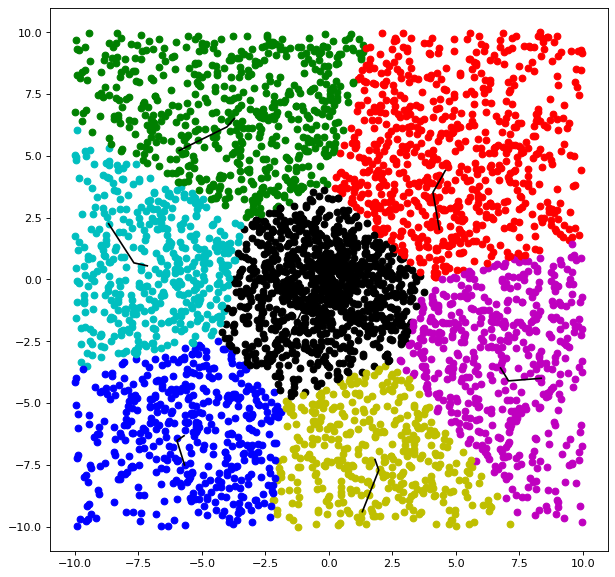

In [18]:
import math
import collections
import random
import copy
import pylab

try:
    import psyco
    psyco.full()
except ImportError:
    pass

FLOAT_MAX = 1e100

class Point:
    __slots__ = ["x", "y", "group"]
    def __init__(self, x = 0, y = 0, group = 0):
        self.x, self.y, self.group = x, y, group

def generatePoints(pointsNumber, radius):
    points = [Point() for _ in range(2 * pointsNumber)]
    count = 0
    for point in points:
        count += 1
        r = random.random() * radius
        angle = random.random() * 2 * math.pi
        point.x = r * math.cos(angle)
        point.y = r * math.sin(angle)
        if count == pointsNumber - 1:
            break
    for index in range(pointsNumber, 2 * pointsNumber):
        points[index].x = 2 * radius * random.random() - radius
        points[index].y = 2 * radius * random.random() - radius
    return points

def solveDistanceBetweenPoints(pointA, pointB):
    return (pointA.x - pointB.x) * (pointA.x - pointB.x) + (pointA.y - pointB.y) * (pointA.y - pointB.y)

def getNearestCenter(point, clusterCenterGroup):
    minIndex = point.group
    minDistance = FLOAT_MAX
    for index, center in enumerate(clusterCenterGroup):
        distance = solveDistanceBetweenPoints(point, center)
        if (distance < minDistance):
            minDistance = distance
            minIndex = index
    return (minIndex, minDistance)

def kMeansPlusPlus(points, clusterCenterGroup):
    clusterCenterGroup[0] = copy.copy(random.choice(points))
    distanceGroup = [0.0 for _ in range(len(points))]
    sum = 0.0
    for index in range(1, len(clusterCenterGroup)):
        for i, point in enumerate(points):
            distanceGroup[i] = getNearestCenter(point, clusterCenterGroup[:index])[1]
            sum += distanceGroup[i]
        sum *= random.random()
        for i, distance in enumerate(distanceGroup):
            sum -= distance;
            if sum < 0:
                clusterCenterGroup[index] = copy.copy(points[i])
                break
    for point in points:
        point.group = getNearestCenter(point, clusterCenterGroup)[0]
    return

def kMeans(points, clusterCenterNumber):
    clusterCenterGroup = [Point() for _ in range(clusterCenterNumber)]
    kMeansPlusPlus(points, clusterCenterGroup)
    clusterCenterTrace = [[clusterCenter] for clusterCenter in clusterCenterGroup]
    tolerableError, currentError = 5.0, FLOAT_MAX
    count = 0
    while currentError >= tolerableError:
        count += 1
        countCenterNumber = [0 for _ in range(clusterCenterNumber)]
        currentCenterGroup = [Point() for _ in range(clusterCenterNumber)]
        for point in points:
            currentCenterGroup[point.group].x += point.x
            currentCenterGroup[point.group].y += point.y
            countCenterNumber[point.group] += 1
        for index, center in enumerate(currentCenterGroup):
            center.x /= countCenterNumber[index]
            center.y /= countCenterNumber[index]
        currentError = 0.0
        for index, singleTrace in enumerate(clusterCenterTrace):
            singleTrace.append(currentCenterGroup[index])
            currentError += solveDistanceBetweenPoints(singleTrace[-1], singleTrace[-2])
            clusterCenterGroup[index] = copy.copy(currentCenterGroup[index])
        for point in points:
            point.group = getNearestCenter(point, clusterCenterGroup)[0]
    return clusterCenterGroup, clusterCenterTrace

def showClusterAnalysisResults(points, clusterCenterTrace):
    colorStore = ['or', 'og', 'ob', 'oc', 'om', 'oy', 'ok']
    pylab.figure(figsize=(9, 9), dpi = 80)
    for point in points:
        color = ''
        if point.group >= len(colorStore):
            color = colorStore[-1]
        else:
            color = colorStore[point.group]
        pylab.plot(point.x, point.y, color)
    for singleTrace in clusterCenterTrace:
        pylab.plot([center.x for center in singleTrace], [center.y for center in singleTrace], 'k')
    pylab.show()

def main():
    clusterCenterNumber = 7
    pointsNumber = 2000
    radius = 10
    points = generatePoints(pointsNumber, radius)
    _, clusterCenterTrace = kMeans(points, clusterCenterNumber)
    showClusterAnalysisResults(points, clusterCenterTrace)
    
main()